In [2]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

import os, json
import pint

u = pint.get_application_registry()


from dspeed.vis.waveform_browser import WaveformBrowser
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.utils import load_data

%matplotlib inline


# RUN 001


In [3]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]
meta  = LegendMetadata(config["metadata"])
chmap = meta.channelmap(meta.dataprod.runinfo.p03.r001.phy.start_key)

In [4]:
data_path

'/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest'

In [5]:
# PRENDO I DATI DI FISICA E NON DI CALIBRAZIONE f"{config["tier_psp"]}/cal/p03/r000/*.lh5" ---> f"{config["tier_psp"]}/phy/p03/r000/*.lh5"
pet_file = sorted(glob.glob(f"{config["tier_pet"]}/phy/l200-p03-r001-phy-tier_pet.lh5"))
psp_file = sorted(glob.glob(f"{config["tier_psp"]}/phy/p03/r001/*.lh5")) #access exsiting DSP-processed data such as the energy for partitions
tcm_file = sorted(glob.glob(f"{config["tier_tcm"]}/phy/p03/r001/*.lh5"))  # --> solo per il pulse
raw_file = sorted(glob.glob(f"{config["tier_raw"]}/phy/p03/r001/*.lh5"))

# cuts --> un solo detector

In [8]:
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 14

In [9]:
channel = f'ch{chmap.V02160A.daq.rawid}'
detector = "V02160A"

In [12]:
cal_file = f"{config["par_pht"]}/cal/p03/r001/l200-p03-r001-cal-20230317T211819Z-par_pht.json"
cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]

In [13]:
params = [ "is_valid_bl_slope_classifier",
         "cuspEmax_ctc_cal"]

In [14]:
# qui mi posso salvare i paramteri di DSP (che ho scelto e definito in config) per lo specfico canale e per tutti gli eventi registrati
start = time.time()
data = load_data(
        files = psp_file,   # da qui prenidmao i dati di dsp già processati 
        lh5_path = f"{channel}/dsp",  # prendo i risultati del dsp per il canale /detcetor specifico
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"],  # lo prendiamo da par_pht
        params=params,
        return_selection_mask=False,)

print(f"[INFO] Took {time.time() - start:.2f} s")


[INFO] Took 27.51 s


In [15]:
# trigger
trigger_data = lh5.read_as("/evt/trigger", pet_file, library="ak")
data["forced_trigger"] = ak.to_numpy(trigger_data['is_forced'])

# pulsesr and coincidences 
coincident_data = lh5.read_as("/evt/coincident", pet_file, library="ak")
data["is_pulser"] = coincident_data['puls']  # no pulser events
data["is_muon"] = coincident_data['muon_offline']  # no muons
data["is_HPGe"] = coincident_data['geds']  # only events with an HPGe signal

# energy selection
mask_lowe =  (data["cuspEmax_ctc_cal"] >=0 ) & (data["cuspEmax_ctc_cal"] < 500)
data["is_below_500keV"] = mask_lowe

### Discharge
geds_data = lh5.read_as("/evt/geds", pet_file, library="ak")
mask_discharge = geds_data.quality.is_not_bb_like.is_delayed_discharge
data["is_discharge"] = mask_discharge



In [16]:
m_fix = data["is_HPGe"]&~data["is_muon"]
m_discharge = ~data["is_discharge"]
m_bl_slope_above5 = (data["is_valid_bl_slope_classifier"] > 5)
    
m_pulser = data["is_pulser"]
m_ft = data["forced_trigger"]
m_lowE = data["is_below_500keV"]

In [17]:
Low_energy_selection =  m_discharge & ~m_pulser & ~m_ft & m_fix & m_lowE & m_bl_slope_above5 
print("voglio vedere vere quali eventi vengono rigettati dai tagli")
print(np.sum(Low_energy_selection), "Low energy events")

voglio vedere vere quali eventi vengono rigettati dai tagli
1 Low energy events


In [18]:
meta.dataprod.runinfo.p03

{'r000': {'cal': {'start_key': '20230311T235840Z'},
  'phy': {'start_key': '20230312T043356Z', 'livetime_in_s': 443740}},
 'r001': {'cal': {'start_key': '20230317T211819Z'},
  'phy': {'start_key': '20230318T015140Z', 'livetime_in_s': 550760}},
 'r002': {'cal': {'start_key': '20230324T161401Z'},
  'phy': {'start_key': '20230324T205907Z', 'livetime_in_s': 554660}},
 'r003': {'cal': {'start_key': '20230331T161141Z'},
  'phy': {'start_key': '20230401T012732Z', 'livetime_in_s': 446340}},
 'r004': {'cal': {'start_key': '20230406T192453Z'},
  'phy': {'start_key': '20230406T235540Z', 'livetime_in_s': 463040}},
 'r005': {'cal': {'start_key': '20230412T124030Z'},
  'phy': {'start_key': '20230412T171450Z', 'livetime_in_s': 58160}}}

In [19]:
dsp_config = meta.dataprod.config.tier_dsp['l200-p01-r%-T%-ICPC-dsp_proc_chain']
print("Available processors:", list(dsp_config['processors'].keys()))
dsp_overrides = meta.dataprod.overrides.dsp.on(meta.dataprod.runinfo.p03.r000.cal.start_key).ch1104000

Available processors: ['wf_presum', 'tp_min, tp_max, wf_min, wf_max', 'wf_mean , wf_std, wf_slope, wf_intercept', 'wf_slope_diff , wf_slope_rms', 'tp_min_win, tp_max_win, wf_min_win, wf_max_win', 'bl_mean_win , bl_std_win, bl_slope_win, bl_intercept_win', 'wf_blsub_win', 'wf_pz_win', 't0_kernel', 'wf_t0_filter', 'wf_atrap', 'wf_t0_smooth', 'conv_tmin ,tp_start, conv_min, conv_max', 'tp_0_atrap', 'tp_0_est', 'bl_mean , bl_std, bl_slope, bl_intercept', 'bl_slope_diff , bl_slope_rms', 'wf_logged', 'wf_blsub', 'tail_pars', 'tail_slope', 'tail_diff, tail_rms', 'wf_pz', 'pz_mean , pz_std, pz_slope, pz_intercept', 'pz_slope_diff, pz_slope_rms', 'dwt_haar', 'dwt_tp_min, dwt_tp_max, dwt_min, dwt_max', 'dwt_norm', 'svm_label', 'wf_trap', 'tp_trapTmin, tp_trapTmax, trapTmin, trapTmax', 'trapTftp', 'wf_trap_short', 'trapSmax', 'wf_pileup_trap', 'baselineEmax', 'tailEmax', 'wf_rc_cr2', 'pos_rc_cr2_thresh', 'neg_rc_cr2_thresh', 'rc_cr2_pileup_n_crossings, rc_cr2_pileup_polarity, rc_cr2_pileup_idxs',

In [21]:
print(list(meta.dataprod.config.tier_dsp.keys()))

['l200-p02-r%-T%-SiPM-dsp_proc_chain', 'l200-p01-r%-T%-COAX-dsp_proc_chain', 'l200-p01-r%-T%-SiPM-dsp_proc_chain', 'l200-p01-r%-T%-ICPC-dsp_proc_chain', 'l200-p02-r%-T%-MUON-dsp_proc_chain']


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)


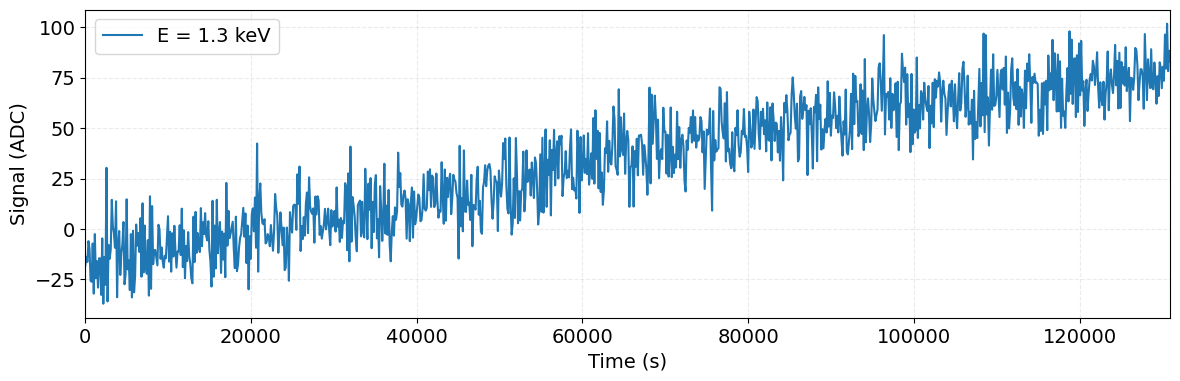

In [22]:
browser = WaveformBrowser(
    raw_file,
    f"{channel}/raw",
    dsp_config=dsp_config,  # Need to include a dsp config file!
    database=dsp_overrides,
    lines=["wf_blsub"],
    aux_values=data,   # dsp data
    #lines=["waveform_presummed"],
    legend=["E = {cuspEmax_ctc_cal} keV"],
    #legend_opts={"loc": "upper left"},
    #legend=["A/E = {AoE_Classifier}"],  # values to put in the legend
    entry_mask=Low_energy_selection,  # apply cut
    n_drawn=3,  # number to draw for draw_next
)

browser.draw_next()

plt.ylabel("Signal (ADC)")
plt.xlabel("Time (ns)")
plt.grid(alpha = 0.25, ls = '--')

# All the detectors run 001

# BL SLOPE

In [ ]:
cal = Props.read_from(cal_file)

In [23]:
# tra tutti i detector che ci sono prendo solo quelli con lo stato di 
# usability = 'on' oppure 'ac'
# processability = True

chmap = meta.channelmap(meta.dataprod.runinfo.p03.r001.phy.start_key)
geds = chmap.group("system").geds

chmap_ak = ak.Array(geds.values())

rawids = ak.to_numpy(chmap_ak.daq.rawid)
names = ak.to_numpy(chmap_ak["name"]).astype(str)

# Leggi la usability di ciascun detector
usability = np.array([
    getattr(det.analysis, "usability", None)
    for det in geds.values()
])

# Tieni tutto tranne i detector con usability == "off"
mask_not_off = (usability != "off")

# (Opzionale) Controlla quali stati sono presenti
print("Usability presenti:", np.unique(usability))

# Maschere per tipo di detector, escludendo solo gli "off"
masks_name = {
    "ICPC": np.char.startswith(names, "V") & mask_not_off,
    "BEGe": np.char.startswith(names, "B") & mask_not_off,
    "Coax": np.char.startswith(names, "C") & mask_not_off,
    "PPC":  np.char.startswith(names, "P") & mask_not_off,
}
det_names = ["ICPC", "BEGe", "Coax", "PPC"]

Usability presenti: ['ac' 'off' 'on']


In [24]:
channels_rawid = {
    det_type: [f"ch{rid}" for rid in rawids[mask]]
    for det_type, mask in masks_name.items()
}

channels_names = {
    det_type: names[mask].tolist()
    for det_type, mask in masks_name.items()
}

print("\nExcluded channels (usability='off' OR processable=False):")

for ch, det in geds.items():

    usability = getattr(det.analysis, "usability", None)
    processable = getattr(det.analysis, "processable", None)

    if (usability == "off") or (processable is False):

        print(
            f"channel={ch:3d} | "
            f"rawid=ch{det.daq.rawid:5d} | "
            f"name={det.name:20s} | "
            f"usability={usability} | "
            f"processable={processable}"
        )

# Riassunto
for det_type in channels_names:
    print(f"\n{det_type}: {len(channels_names[det_type])} detector")
    print(channels_names[det_type])


Excluded channels (usability='off' OR processable=False):
channel= 17 | rawid=ch1108804 | name=V07298B              | usability=off | processable=False
channel= 21 | rawid=ch1110405 | name=P00665A              | usability=off | processable=False
channel= 34 | rawid=ch1115200 | name=V01386A              | usability=off | processable=False
channel= 35 | rawid=ch1115201 | name=V01403A              | usability=off | processable=False
channel= 36 | rawid=ch1115202 | name=V01404A              | usability=off | processable=False
channel= 64 | rawid=ch1080002 | name=B00091D              | usability=off | processable=False
channel= 65 | rawid=ch1080003 | name=P00537A              | usability=off | processable=False
channel= 74 | rawid=ch1083200 | name=B00091B              | usability=off | processable=False
channel= 91 | rawid=ch1088000 | name=P00538B              | usability=off | processable=False
channel= 95 | rawid=ch1088004 | name=P00661A              | usability=off | processable=False
c

In [28]:
cal_file = f"{config["par_pht"]}/cal/p03/r001/l200-p03-r001-cal-20230317T211819Z-par_pht.json"
trigger_data = lh5.read_as("/evt/trigger", pet_file, library="ak")
coincident_data = lh5.read_as("/evt/coincident", pet_file, library="ak")

In [31]:
dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]

detector_type = "ICPC"
output_pdf = "waveforms_ICPC_r01.pdf"
params = [
    "is_valid_bl_slope_classifier",
    "is_valid_bl_slope",
    "cuspEmax_ctc_cal"
]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])

channels_list = channels_rawid[detector_type]

with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_250keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 250)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_250keV = data["is_below_250keV"]
        bl_slope = data["is_valid_bl_slope_classifier"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_bl_slope = bl_slope > 5
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_250keV &
            m_bl_slope
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=["wf_blsub"],
            aux_values=data,
            legend=["E = {cuspEmax_ctc_cal} keV"],
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
        )
    
        browser.draw_next()
    
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (ns)")
        plt.grid(alpha=0.25, ls="--")

        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)
        print("======= FINISHED ==============")

0it [00:00, ?it/s]


==================================== ch1104000 1/37 ====================================

1 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
1it [00:14, 14.77s/it]

======= FINISHED ==============

==================================== ch1104001 2/37 ====================================

3 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
2it [00:29, 14.67s/it]

...

======= FINISHED ==============

==================================== ch1086400 36/37 ====================================

32 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
36it [11:00, 19.50s/it]

======= FINISHED ==============

==================================== ch1086401 37/37 ====================================

14 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
37it [11:20, 18.38s/it]

======= FINISHED ==============


In [32]:
dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]
output_pdf = "waveforms_bege_R001.pdf"
detector_type = "BEGe"
params = [
    "is_valid_bl_slope_classifier",
    "is_valid_bl_slope",
    "cuspEmax_ctc_cal"
]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])

channels_list = channels_rawid[detector_type]

with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_250keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 250)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_250keV = data["is_below_250keV"]
        bl_slope = data["is_valid_bl_slope_classifier"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_bl_slope = bl_slope > 5
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_250keV &
            m_bl_slope
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=["wf_blsub"],
            aux_values=data,
            legend=["E = {cuspEmax_ctc_cal} keV"],
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
        )
    
        browser.draw_next()
    
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (s)")
        plt.grid(alpha=0.25, ls="--")
    
        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)

0it [00:00, ?it/s]


==================================== ch1107202 1/26 ====================================

3 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
1it [00:20, 20.99s/it]


==================================== ch1110402 2/26 ====================================

4 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
2it [00:42, 21.51s/it]

...

/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
24it [06:27, 13.78s/it]


==================================== ch1086404 25/26 ====================================

1 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
25it [06:41, 13.87s/it]


==================================== ch1086405 26/26 ====================================

2 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
26it [06:55, 15.99s/it]


In [117]:
import os
os.getcwd()

'/global/u2/r/ritaferi'

In [33]:
dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]
output_pdf = "waveforms_ppc_R001.pdf"
detector_type = "PPC"
params = [
    "is_valid_bl_slope_classifier",
    "is_valid_bl_slope",
    "cuspEmax_ctc_cal"
]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])

channels_list = channels_rawid[detector_type]

with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_250keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 250)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_250keV = data["is_below_250keV"]
        bl_slope = data["is_valid_bl_slope_classifier"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_bl_slope = bl_slope > 5
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_250keV &
            m_bl_slope
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=["wf_blsub"],
            aux_values=data,
            legend=["E = {cuspEmax_ctc_cal} keV"],
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
        )
    
        browser.draw_next()
    
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (s)")
        plt.grid(alpha=0.25, ls="--")
    
        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)

0it [00:00, ?it/s]


==================================== ch1110404 1/20 ====================================

3 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
1it [00:13, 13.04s/it]


==================================== ch1112000 2/20 ====================================

3 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
2it [00:26, 13.54s/it]

...

/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
18it [04:10, 14.53s/it]


==================================== ch1089601 19/20 ====================================

1 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
19it [04:24, 14.36s/it]


==================================== ch1089603 20/20 ====================================

8 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
20it [04:39, 13.99s/it]


In [42]:
# coax


dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]
output_pdf = "waveforms_coax_R001.pdf"
detector_type = "Coax"
params = [
    "is_valid_bl_slope_classifier",
    "is_valid_bl_slope",
    "cuspEmax_ctc_cal"
]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])

channels_list = channels_rawid[detector_type][:3]

with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_250keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 250)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_250keV = data["is_below_250keV"]
        bl_slope = data["is_valid_bl_slope_classifier"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_bl_slope = bl_slope > 5
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_250keV &
            m_bl_slope
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
        
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=["wf_blsub"],
            aux_values=data,
            legend = None if n_selected > 10 else ["E = {cuspEmax_ctc_cal:.1f} keV"],
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
        )
    
        browser.draw_next()
    
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (s)")
        plt.grid(alpha=0.25, ls="--")
    
        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)

0it [00:00, ?it/s]


==================================== ch1107203 1/3 ====================================



1it [00:10, 10.44s/it]

0 Low energy events
No events → skipping channel

==================================== ch1107204 2/3 ====================================

31 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
2it [00:23, 12.17s/it]


==================================== ch1107205 3/3 ====================================

37 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
3it [00:38, 12.70s/it]


# bl_slope_RMS

In [36]:
channels_tot = []

for ch, det in geds.items():

    usability = getattr(det.analysis, "usability", None)
    processable = getattr(det.analysis, "processable", None)

    if usability in ("on", "ac"):
        channels_tot.append(f"ch{det.daq.rawid}")

In [43]:
# coax


dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]
output_pdf = "waveforms_bl_slope_RMS_R001.pdf"
params = [
    #"is_valid_bl_slope_classifier",
    "is_valid_bl_slope",
    "is_valid_bl_slope_rms_classifier",
    "is_valid_bl_slope_rms",
    "cuspEmax_ctc_cal"
]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])
channels_list = channels_tot
with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_250keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 250)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_250keV = data["is_below_250keV"]
        bl_slope = data["is_valid_bl_slope"]

        bl_slope_rms_class = data["is_valid_bl_slope_rms_classifier"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_qc = bl_slope 

        m_bl_slope_rms = bl_slope_rms_class > 5  # taglio per guardare gli eventi che verrebbero rigettati dal taglio in analisi
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_250keV &
            m_qc &
            m_bl_slope_rms
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=["wf_blsub"],
            aux_values=data,
            legend=["E = {cuspEmax_ctc_cal} keV"],
            legend_opts={"loc": "lower right"},
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
        )
    
        browser.draw_next()
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (s)")
        plt.grid(alpha=0.25, ls="--")
    
        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)

print("=======================  finished ===========================")

0it [00:00, ?it/s]


==================================== ch1104000 1/89 ====================================

1 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
1it [00:32, 32.98s/it]


==================================== ch1104001 2/89 ====================================

4 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
2it [00:47, 22.39s/it]

...


==================================== ch1116802 36/89 ====================================

83 Low energy events


/opt/conda/lib/python3.12/site-packages/dspeed/processing_chain.py:1571: RuntimeWarning: invalid value encountered in divide
  self.processor(*self.args, **self.kwargs)
36it [08:05, 15.99s/it]


==================================== ch1116803 37/89 ====================================

79 Low energy events


idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx indexed past the end of the array in the file. Culling...
idx inde

ValueError: non-broadcastable output operand with shape (1,) doesn't match the broadcast shape (2,)

# taill rms

In [34]:
channels_tot;

In [ ]:
dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]
output_pdf = "waveforms_tail_RMS_R001.pdf"
params = [
    #"is_valid_bl_slope_classifier",
    "is_valid_bl_slope",
    #"is_valid_bl_slope_rms_classifier",
    "is_valid_bl_slope_rms",
    "is_valid_tail_rms_classifier",
    "is_valid_tail_rms",
    "cuspEmax_ctc_cal"
]
#channels_list = channels_rawid[detector_type]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])
channels_list = channels_tot
with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_250keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 250)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_250keV = data["is_below_250keV"]
        bl_slope = data["is_valid_bl_slope"]
        bl_slope_rms_class = data["is_valid_bl_slope_rms"]

        tail_rms_class = data["is_valid_tail_rms_classifier"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_qc = bl_slope & bl_slope_rms_class

        m_tail_rms = tail_rms_class > 5  # taglio per guardare gli eventi che verrebbero rigettati dal taglio in analisi
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_250keV &
            m_qc &
            m_tail_rms
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=[#"wf_blsub",
                    "wf_pz"],
            aux_values=data,
            legend=["E = {cuspEmax_ctc_cal} keV"],
            legend_opts={"loc": "lower right"},
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
        )
    
        browser.draw_next()
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (ns)")
        plt.grid(alpha=0.25, ls="--")
    
        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)

print("=======================  finished ===========================")

# trap TpMAX

In [52]:
meta.dataprod.config.tier_dsp

TextDB('/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5/inputs/dataprod/config/tier_dsp')

In [ ]:
dsp_config = meta.dataprod.config.tier_dsp[
    'l200-p01-r%-T%-ICPC-dsp_proc_chain'
]
output_pdf = "waveforms_tp_TrapMax_passed_R001.pdf"
params = [
    "is_valid_bl_slope",
    "is_valid_bl_slope_rms",
    "is_valid_tail_rms",
    "is_not_noise_burst",
    "is_valid_cuspEmin",
    "is_valid_cuspEmax",
    "tp_trapTmax",
    "cuspEmax_ctc_cal"
]
#channels_list = channels_rawid[detector_type]

# --------------------------
# PRE-CACHING (fuori loop)
# --------------------------
start_key = meta.dataprod.runinfo.p03.r001.cal.start_key
dsp_overrides_all = meta.dataprod.overrides.dsp.on(start_key)

forced_trigger_np = ak.to_numpy(trigger_data["is_forced"])
channels_list = channels_tot
with PdfPages(output_pdf) as pdf:
    for i, channel in tqdm(enumerate(channels_list)):
        print(f"\n==================================== {channel} {i+1}/{len(channels_list)} ====================================\n")
    
        # --------------------------
        # CALIBRAZIONE
        # --------------------------
        cal_dict = Props.read_from(cal_file)[channel]["pars"]["operations"]
    
        # --------------------------
        # LOAD DATA (NO COPY)
        # --------------------------
        data = load_data(
            files=psp_file,
            lh5_path=f"{channel}/dsp",
            cal_dict=cal_dict,
            params=params,
            return_selection_mask=False,
        )
    
        # --------------------------
        # FLAGS GLOBALI
        # --------------------------
        data["forced_trigger"] = forced_trigger_np
        data["is_pulser"] = coincident_data["puls"]
        data["is_muon"] = coincident_data["muon_offline"]
        data["is_HPGe"] = coincident_data["geds"]
    
        data["is_discharge"] = geds_data.quality.is_not_bb_like.is_delayed_discharge
    
        data["is_below_100keV"] = (
            (data["cuspEmax_ctc_cal"] > 0) &
            (data["cuspEmax_ctc_cal"] < 40)
        )
    
        # --------------------------
        # CACHE LOCALI (IMPORTANTE)
        # --------------------------
        is_hpge = data["is_HPGe"]
        is_muon = data["is_muon"]
        is_pulser = data["is_pulser"]
        forced_trigger = data["forced_trigger"]
        is_discharge = data["is_discharge"]
        is_below_100keV = data["is_below_100keV"]
        bl_slope = data["is_valid_bl_slope"]
        bl_slope_rms_class = data["is_valid_bl_slope_rms"]
        tail_rms_class = data["is_valid_tail_rms"]
        noise_burst = data["is_not_noise_burst"]
        cuspEmin = data["is_valid_cuspEmin"]
        cuspEmax = data["is_valid_cuspEmax"]
    
        # --------------------------
        # MASCHERE
        # --------------------------
        m_fix = is_hpge & ~is_muon
        m_discharge = ~is_discharge
        m_qc = bl_slope & bl_slope_rms_class & tail_rms_class & noise_burst & cuspEmin & ~cuspEmax

        m_failed_trapTmax = (data["tp_trapTmax"] > 55000 ) & ( data["tp_trapTmax"] < 65000)
    
        # --------------------------
        # SELEZIONE
        # --------------------------
        low_energy_selection = (
            m_discharge &
            ~is_pulser &
            ~forced_trigger &
            m_fix &
            is_below_100keV &
            m_qc &
            m_failed_trapTmax
        )
    
        n_selected = int(np.sum(low_energy_selection))
        print(n_selected, "Low energy events")
    
        if n_selected == 0:
            print("No events → skipping channel")
            continue
    
        # --------------------------
        # OVERRIDES DSP
        # --------------------------
        dsp_overrides = dsp_overrides_all[channel]
    
        # --------------------------
        # BROWSER
        # --------------------------
        # colormap fredda
        cmap = plt.cm.Blues  # alternativa: plt.cm.Greys, plt.cm.cividis
        
        n = n_selected
        colors = cmap(np.linspace(0.3, 0.95, n))
        browser = WaveformBrowser(
            raw_file,
            f"{channel}/raw",
            dsp_config=dsp_config,
            database=dsp_overrides,
            lines=[#"wf_blsub",
                    "wf_pz",],
                    #"wf_trap",],
                    #"cuspEmax",],
            aux_values=data,
            legend=["E = {cuspEmax_ctc_cal} keV"],
            legend_opts={"loc": "lower right"},
            entry_mask=low_energy_selection,
            n_drawn=n_selected,
            styles={"color": colors}
            
        )
    
        browser.draw_next()
        plt.title(f"chn : {channel}")
        plt.ylabel("Signal (ADC)")
        plt.xlabel("Time (ns)")
        plt.grid(alpha=0.25, ls="--")
    
        fig = plt.gcf()   # prende la figura corrente

        pdf.savefig(fig)
        plt.close(fig)

print("=======================  finished ===========================")